# 🎯 Projeto de 1 Fator — Domínio (4 datasets)

Aprofunda o **fator Domínio** (que no fatorial 2³ explicou ~16–21% da variação),
isolando-o num **projeto de um fator** com **replicação**:

$$y_{ij} = \mu + \tau_i + e_{ij}$$

- **Fator (1):** `dataset` com **4 níveis** — AGNews, MovieReview (geral) e DBLP,
  Books (técnico).
- **Resposta** $y_{ij}$: **F1-macro** (e **Acurácia**) do **consenso por voto
  majoritário** da réplica *j* do dataset *i* (cobertura ≈ 100%), reutilizando
  `ConsensusCalculator`.
- **Réplicas:** as pastas com *timestamp* (`YYYY-MM-DD_HH-MM-SS`), que vêm **após**
  a pasta "… - 3 modelos".

> ⚠️ **Estado dos dados:** hoje **MovieReview e Books têm 5 réplicas**; **AGNews e
> DBLP ainda estão sendo coletadas**. O notebook **roda com o que existe** (desenho
> desbalanceado, resultados parciais) e fica **pronto para 5/5/5/5** — basta as
> novas pastas aparecerem.

**Saídas:** tabela ANOVA (SS, g.l., MS, F, p, % de variação), efeitos e IC por
nível, comparações múltiplas (Tukey HSD) e **premissas** (normalidade,
homoscedasticidade, independência) **antes** da análise.


## 1) Setup e configuração

In [1]:
import os
import sys
import re
import glob
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import accuracy_score, f1_score
from loguru import logger

ROOT = Path.cwd()
while not (ROOT / "data" / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.llm_annotation_system.consensus.consensus_calculator import ConsensusCalculator
from src.llm_annotation_system.consensus.consensus_evaluator import ConsensusEvaluator

logger.remove()
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"] = 110

MODELS = ["deepseek-r1-8b", "qwen3-8b", "llama3.1-8b"]
CONS_COLS = [f"{m}_consensus" for m in MODELS]

# 4 níveis do fator domínio (ordem geral -> técnico)
DATASETS = ["agnews", "movie_review", "dblp", "books"]
DOMINIO = {"agnews": "geral", "movie_review": "geral", "dblp": "técnico", "books": "técnico"}
N_REPS = 5          # alvo de réplicas por nível
INVALID = -1

RESULTS_DIR = ROOT / "data" / "results"
print("Raiz do projeto:", ROOT)

Raiz do projeto: C:\Users\gabri\Documents\GitHub\llm-annotation


## 2) Selecionar as réplicas (pastas com *timestamp*)

São as pastas cujo nome começa com `YYYY-MM-DD_HH-MM-SS` (as que vêm **após** a
pasta "… - 3 modelos"). Pegamos até **5** por dataset.

In [2]:
TS = re.compile(r"^\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}")


def replication_folders(dataset, n=N_REPS):
    """Pastas de réplica (timestamp) com annotations.csv, no máximo as n últimas."""
    folders = sorted(
        d for d in glob.glob(str(RESULTS_DIR / dataset / "*") + os.sep)
        if os.path.exists(os.path.join(d, "annotations.csv"))
        and TS.match(os.path.basename(d.rstrip(os.sep)))
    )
    return folders[-n:]


REPLICATION_FOLDERS = {ds: replication_folders(ds) for ds in DATASETS}

print("Réplicas encontradas por dataset:")
incompletos = []
for ds in DATASETS:
    fs = REPLICATION_FOLDERS[ds]
    flag = "" if len(fs) == N_REPS else f"  ⚠️ faltam {N_REPS - len(fs)}"
    if len(fs) != N_REPS:
        incompletos.append(ds)
    print(f"  {ds:13s} ({DOMINIO[ds]:7s}): {len(fs)} réplica(s){flag}")
    for f in fs:
        print(f"        - {os.path.basename(os.path.normpath(f))}")

if incompletos:
    print(f"\n⚠️ DESENHO INCOMPLETO: {incompletos} ainda sem 5 réplicas → "
          "resultados PARCIAIS (desbalanceado). Reexecute quando a coleta terminar.")
else:
    print("\n✓ Desenho completo: 4 níveis × 5 réplicas = 20 observações.")

Réplicas encontradas por dataset:
  agnews        (geral  ): 1 réplica(s)  ⚠️ faltam 4
        - 2026-04-09_13-20-16 - rep1
  movie_review  (geral  ): 5 réplica(s)
        - 2026-04-09_13-17-23
        - 2026-05-17_14-44-16
        - 2026-05-17_21-51-31
        - 2026-05-18_06-14-02
        - 2026-05-18_22-29-27
  dblp          (técnico): 1 réplica(s)  ⚠️ faltam 4
        - 2026-04-09_14-05-21
  books         (técnico): 5 réplica(s)
        - 2026-04-09_13-21-37
        - 2026-05-20_21-44-17
        - 2026-05-23_00-20-50
        - 2026-05-24_20-47-50
        - 2026-05-26_18-26-27

⚠️ DESENHO INCOMPLETO: ['agnews', 'dblp'] ainda sem 5 réplicas → resultados PARCIAIS (desbalanceado). Reexecute quando a coleta terminar.


## 3) Resposta por réplica — F1/Acurácia do consenso (voto majoritário)

Para cada réplica, o consenso por **voto majoritário** (classe mais votada entre
os 3 modelos) é avaliado contra o `ground_truth`. Limpeza padrão: descarta
`ground_truth`/`resolved_annotation` inválidos e casos problemáticos.

In [3]:
def get_categories(df):
    return sorted(int(v) for v in df["ground_truth"].unique() if v != INVALID)


def consensus_quality(df_raw, categories, output_dir):
    """F1-macro, acurácia e cobertura do consenso por maioria de uma réplica."""
    calc = ConsensusCalculator(consensus_threshold=0.8, default_strategy="majority_vote")
    ev = ConsensusEvaluator(categories=categories, calculator=calc, output_dir=output_dir)
    sub = df_raw[["text_id", "text", "ground_truth"] + CONS_COLS].copy()
    dfc = ev.compute_consensus(sub)
    dfc = dfc[dfc["ground_truth"] != INVALID]
    covered = dfc[
        dfc["resolved_annotation"].notna()
        & (dfc["resolved_annotation"] != INVALID)
        & (~dfc["is_problematic"])
    ]
    y_true = covered["ground_truth"].astype(int)
    y_pred = covered["resolved_annotation"].astype(int)
    return {
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "coverage": len(covered) / len(dfc) if len(dfc) else 0.0,
        "n_cobertos": len(covered),
    }

## 4) Tabela do experimento (uma linha por réplica)

In [4]:
rows = []
for ds in DATASETS:
    for rep_idx, folder in enumerate(REPLICATION_FOLDERS[ds], start=1):
        df_raw = pd.read_csv(os.path.join(folder, "annotations.csv"))
        cats = get_categories(df_raw)
        q = consensus_quality(df_raw, cats, folder)
        rows.append({
            "dataset": ds, "dominio": DOMINIO[ds], "replica": rep_idx,
            "pasta": os.path.basename(os.path.normpath(folder)), **q,
        })

df1 = pd.DataFrame(rows)
print("Observações:", len(df1), f"(alvo: 4 × {N_REPS} = {4 * N_REPS})")
print("Réplicas por dataset:")
print(df1.groupby("dataset").size().reindex(DATASETS))
df1

Observações: 12 (alvo: 4 × 5 = 20)
Réplicas por dataset:
dataset
agnews          1
movie_review    5
dblp            1
books           5
dtype: int64


,dataset,dominio,replica,pasta,f1_macro,accuracy,coverage,n_cobertos
0,agnews,geral,1,2026-04-09_13-20-16 - rep1,0.8652,0.8676,0.9977,127309
1,movie_review,geral,1,2026-04-09_13-17-23,0.9135,0.9135,0.9992,10653
2,movie_review,geral,2,2026-05-17_14-44-16,0.9131,0.9131,0.9988,10649
3,movie_review,geral,3,2026-05-17_21-51-31,0.9124,0.9124,0.9989,10650
4,movie_review,geral,4,2026-05-18_06-14-02,0.9142,0.9142,0.9987,10648
5,movie_review,geral,5,2026-05-18_22-29-27,0.9126,0.9126,0.9994,10656
6,dblp,técnico,1,2026-04-09_14-05-21,0.6202,0.6456,0.9786,37238
7,books,técnico,1,2026-04-09_13-21-37,0.7372,0.7235,0.9825,33005
8,books,técnico,2,2026-05-20_21-44-17,0.7366,0.7230,0.9833,33034
9,books,técnico,3,2026-05-23_00-20-50,0.7376,0.7238,0.9832,33029


## 5) Função de análise de 1 fator (ANOVA one-way)

Decomposição (suporta desenho **desbalanceado**, $n_i$ por nível):

- $SS_{fator} = \sum_i n_i (\bar{y}_i - \bar{y}_{..})^2$ ; $g.l. = a-1$
- $SS_{erro} = \sum_i \sum_j (y_{ij} - \bar{y}_i)^2$ ; $g.l. = N-a$
- $MS = SS/g.l.$ ; $F = MS_{fator}/MS_{erro}$ ; **% variação** $= SS_{fator}/SS_{total}$
- Efeito do nível $i$: $\hat{\tau}_i = \bar{y}_i - \bar{y}_{..}$
- IC da média do nível: $\bar{y}_i \pm t_{1-\alpha/2;\,N-a}\sqrt{MS_{erro}/n_i}$

In [5]:
def one_way_anova(data, response, factor="dataset", alpha=0.05):
    grp = data.groupby(factor, sort=False)[response]
    levels = list(grp.groups.keys())
    ni = grp.count().to_numpy(dtype=float)
    means = grp.mean().to_numpy()
    y = data[response].to_numpy(dtype=float)
    N, a = len(y), len(levels)
    grand = y.mean()

    SSA = float(np.sum(ni * (means - grand) ** 2))
    SSE = float(sum(((g.to_numpy() - g.mean()) ** 2).sum() for _, g in grp))
    SST = SSA + SSE
    dfA, dfE = a - 1, N - a
    MSA = SSA / dfA if dfA > 0 else np.nan
    MSE = SSE / dfE if dfE > 0 else np.nan
    F = MSA / MSE if (MSE is not None and MSE > 0) else np.nan
    pval = float(stats.f.sf(F, dfA, dfE)) if np.isfinite(F) else np.nan
    tcrit = stats.t.ppf(1 - alpha / 2, dfE) if dfE > 0 else np.nan

    anova = pd.DataFrame({
        "fonte": [f"{factor} (entre níveis)", "Erro (entre réplicas)", "Total"],
        "SS": [SSA, SSE, SST],
        "g.l.": [dfA, dfE, N - 1],
        "MS": [MSA, MSE, np.nan],
        "F": [F, np.nan, np.nan],
        "p_value": [pval, np.nan, np.nan],
        "% variação": [100 * SSA / SST, 100 * SSE / SST, 100.0] if SST > 0 else [np.nan] * 3,
    })

    se_i = np.sqrt(MSE / ni) if (MSE is not None and MSE > 0) else np.full(a, np.nan)
    niveis = pd.DataFrame({
        factor: levels,
        "n": ni.astype(int),
        "media": means,
        "efeito (média − geral)": means - grand,
        "IC_low": means - tcrit * se_i,
        "IC_high": means + tcrit * se_i,
    })
    return {
        "response": response, "anova": anova, "niveis": niveis,
        "F": F, "p_value": pval, "MSE": MSE, "dfE": dfE, "grand_mean": grand,
        "SSA": SSA, "SSE": SSE, "SST": SST, "tcrit": tcrit, "N": N, "a": a,
        "pct_fator": 100 * SSA / SST if SST > 0 else np.nan,
    }

## 6) Premissas do modelo — **verificadas antes da análise**

Resíduos $e_{ij} = y_{ij} - \bar{y}_{i}$ devem ser **independentes, normais e
homoscedásticos**:

- **Normalidade** — Shapiro-Wilk + histograma + QQ-plot.
- **Homoscedasticidade** — **Levene** (mediana) e **Bartlett** entre os níveis +
  resíduos × ajustados.
- **Independência** — **Durbin-Watson**.

> Testes de variância/normalidade usam apenas níveis com **≥ 2 réplicas** (enquanto
> AGNews/DBLP tiverem 1, ficam de fora desses testes). Reavaliamos após
> **transformação logit**.

Premissas (resíduos) — F1 e Acurácia:


,resposta,niveis_>=2rep,Shapiro_W,Shapiro_p,normal_ok(5%),Levene_p,Bartlett_p,homoced_ok(5%),Durbin_Watson
0,f1_macro,2,0.9562,0.7416,True,0.3395,0.3740,True,2.6959
1,accuracy,2,0.9513,0.6834,True,0.1606,0.1799,True,2.9074


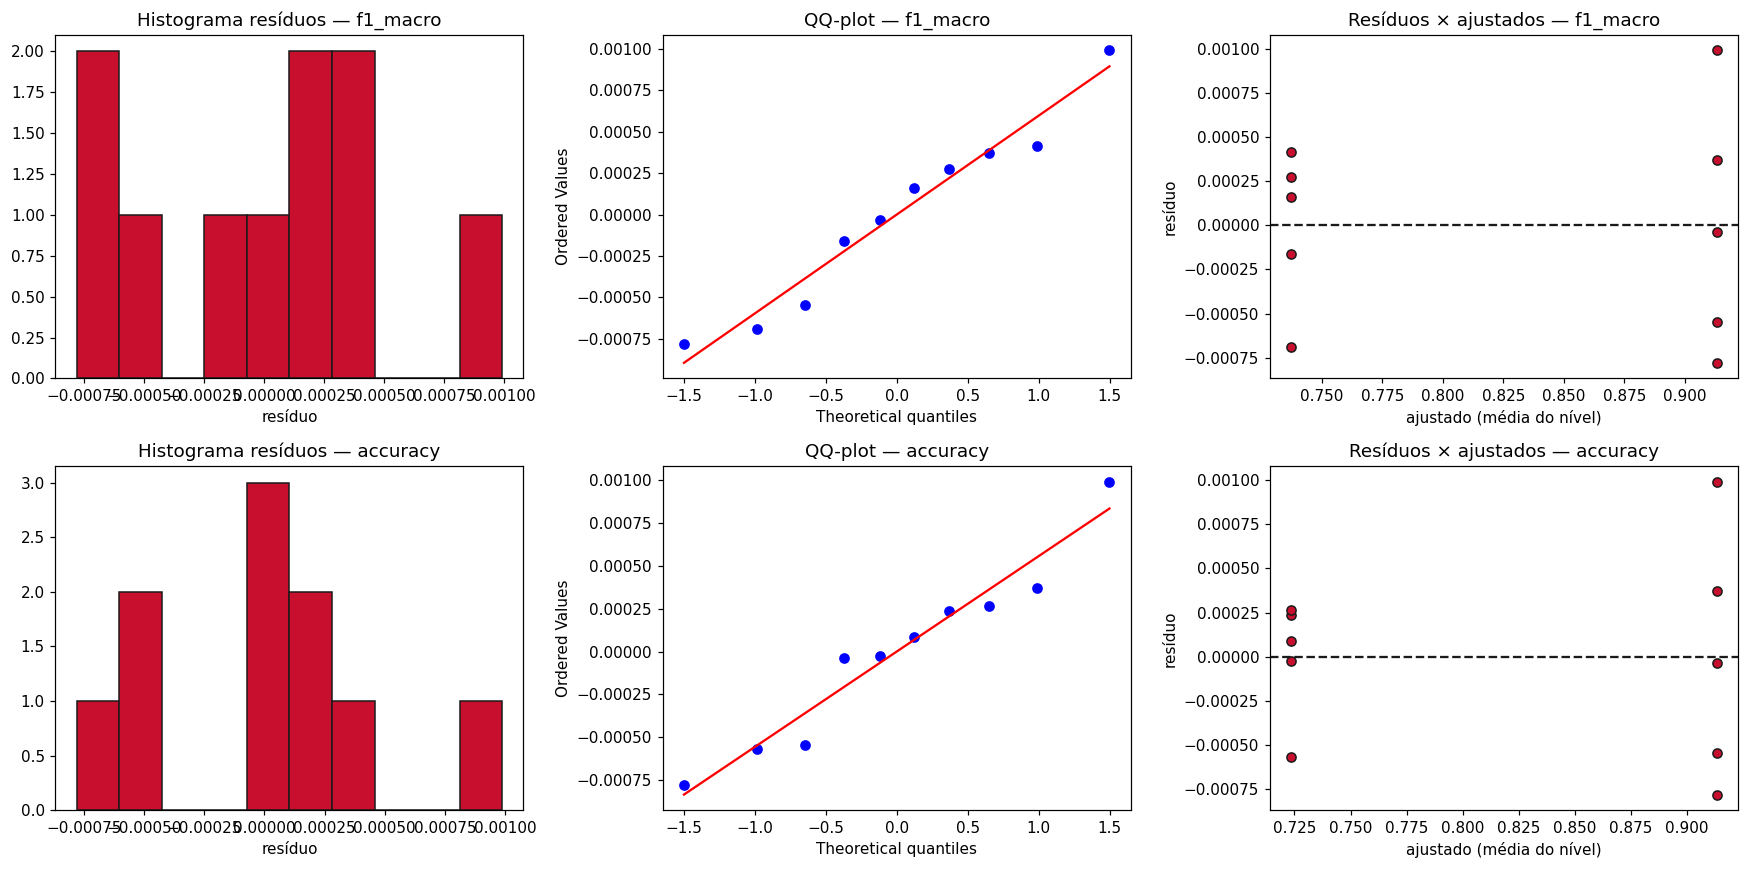

Reteste após transformação logit:


,resposta,niveis_>=2rep,Shapiro_W,Shapiro_p,normal_ok(5%),Levene_p,Bartlett_p,homoced_ok(5%),Durbin_Watson
0,f1_logit,2,0.9612,0.7992,True,0.0539,0.0215,True,3.0262
1,acc_logit,2,0.9423,0.5790,True,0.0350,0.0074,False,3.0696


In [6]:
def _residuos(data, response, factor="dataset"):
    d = data.copy()
    d["_fitted"] = d.groupby(factor)[response].transform("mean")
    d["_resid"] = d[response] - d["_fitted"]
    return d


def testar_premissas(data, response, factor="dataset"):
    d = _residuos(data, response, factor)
    grupos2 = [g for _, g in d.groupby(factor) if len(g) >= 2]   # >=2 p/ variância
    out = {"resposta": response, "niveis_>=2rep": len(grupos2)}
    if not grupos2:
        out["aviso"] = "sem níveis com ≥2 réplicas — colete mais dados"
        return out
    resid = np.concatenate([g["_resid"].to_numpy() for g in grupos2])
    if len(resid) >= 3:
        W, p = stats.shapiro(resid)
        out.update({"Shapiro_W": W, "Shapiro_p": p, "normal_ok(5%)": p >= 0.05})
    if len(grupos2) >= 2:
        gg = [g[response].to_numpy() for g in grupos2]
        out["Levene_p"] = stats.levene(*gg, center="median")[1]
        out["Bartlett_p"] = stats.bartlett(*gg)[1]
        out["homoced_ok(5%)"] = out["Levene_p"] >= 0.05
    out["Durbin_Watson"] = float(np.sum(np.diff(resid) ** 2) / np.sum(resid ** 2))
    return out


print("Premissas (resíduos) — F1 e Acurácia:")
display(pd.DataFrame([testar_premissas(df1, "f1_macro"),
                      testar_premissas(df1, "accuracy")]))


# ---- gráficos de diagnóstico (níveis com ≥2 réplicas) ----
def plot_residuos(data, response, axes, factor="dataset"):
    d = _residuos(data, response, factor)
    d = pd.concat([g for _, g in d.groupby(factor) if len(g) >= 2]) if \
        any(len(g) >= 2 for _, g in d.groupby(factor)) else d
    resid = d["_resid"].to_numpy(); fitted = d["_fitted"].to_numpy()
    axes[0].hist(resid, bins=10, color="#C8102E", edgecolor="#1A1A1A")
    axes[0].set_title(f"Histograma resíduos — {response}"); axes[0].set_xlabel("resíduo")
    if len(resid) >= 3:
        stats.probplot(resid, dist="norm", plot=axes[1])
    axes[1].set_title(f"QQ-plot — {response}")
    axes[2].scatter(fitted, resid, color="#C8102E", edgecolor="#1A1A1A")
    axes[2].axhline(0, color="#1A1A1A", ls="--")
    axes[2].set_xlabel("ajustado (média do nível)"); axes[2].set_ylabel("resíduo")
    axes[2].set_title(f"Resíduos × ajustados — {response}")


fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_residuos(df1, "f1_macro", axes[0])
plot_residuos(df1, "accuracy", axes[1])
plt.tight_layout(); plt.show()


# ---- remédio: transformação logit e reteste ----
def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

_dl = df1.copy()
_dl["f1_logit"] = _logit(_dl["f1_macro"])
_dl["acc_logit"] = _logit(_dl["accuracy"])
print("Reteste após transformação logit:")
display(pd.DataFrame([testar_premissas(_dl, "f1_logit"),
                      testar_premissas(_dl, "acc_logit")]))

## 7) ANOVA de 1 fator — Resposta = **F1 Macro**

In [7]:
res_f1 = one_way_anova(df1, "f1_macro")
print(f"F = {res_f1['F']:.3f}  |  p = {res_f1['p_value']:.3g}  |  "
      f"g.l. = ({res_f1['a'] - 1}, {res_f1['dfE']})  |  "
      f"domínio explica {res_f1['pct_fator']:.1f}% da variação")
print("\nTabela ANOVA (F1):")
display(res_f1["anova"])
print("Médias, efeitos e IC 95% por nível (F1):")
display(res_f1["niveis"])

F = 112951.023  |  p = 7.64e-19  |  g.l. = (3, 8)  |  domínio explica 100.0% da variação

Tabela ANOVA (F1):


,fonte,SS,g.l.,MS,F,p_value,% variação
0,dataset (entre níveis),0.1187,3,0.0396,112951.0227,0.0000,99.9976
1,Erro (entre réplicas),0.0000,8,0.0000,NaN,NaN,0.0024
2,Total,0.1187,11,NaN,NaN,NaN,100.0000


Médias, efeitos e IC 95% por nível (F1):


,dataset,n,media,efeito (média − geral),IC_low,IC_high
0,agnews,1,0.8652,0.0537,0.8638,0.8665
1,movie_review,5,0.9132,0.1017,0.9126,0.9138
2,dblp,1,0.6202,-0.1913,0.6188,0.6215
3,books,5,0.7373,-0.0742,0.7367,0.7379


### Comparações múltiplas — Tukey HSD (F1)

In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if df1.groupby("dataset").size().min() >= 2:
    tk = pairwise_tukeyhsd(df1["f1_macro"], df1["dataset"], alpha=0.05)
    print(tk)
else:
    print("Tukey HSD requer ≥2 réplicas por nível — pendente até AGNews/DBLP terem réplicas.")

Tukey HSD requer ≥2 réplicas por nível — pendente até AGNews/DBLP terem réplicas.


## 8) ANOVA de 1 fator — Resposta = **Acurácia**

In [9]:
res_acc = one_way_anova(df1, "accuracy")
print(f"F = {res_acc['F']:.3f}  |  p = {res_acc['p_value']:.3g}  |  "
      f"g.l. = ({res_acc['a'] - 1}, {res_acc['dfE']})  |  "
      f"domínio explica {res_acc['pct_fator']:.1f}% da variação")
print("\nTabela ANOVA (Acurácia):")
display(res_acc["anova"])
display(res_acc["niveis"])

F = 130199.382  |  p = 4.33e-19  |  g.l. = (3, 8)  |  domínio explica 100.0% da variação

Tabela ANOVA (Acurácia):


,fonte,SS,g.l.,MS,F,p_value,% variação
0,dataset (entre níveis),0.1209,3,0.0403,130199.3822,0.0000,99.9980
1,Erro (entre réplicas),0.0000,8,0.0000,NaN,NaN,0.0020
2,Total,0.1209,11,NaN,NaN,NaN,100.0000


,dataset,n,media,efeito (média − geral),IC_low,IC_high
0,agnews,1,0.8676,0.0596,0.8664,0.8689
1,movie_review,5,0.9132,0.1051,0.9126,0.9137
2,dblp,1,0.6456,-0.1625,0.6443,0.6469
3,books,5,0.7236,-0.0845,0.7230,0.7241


## 9) Gráficos

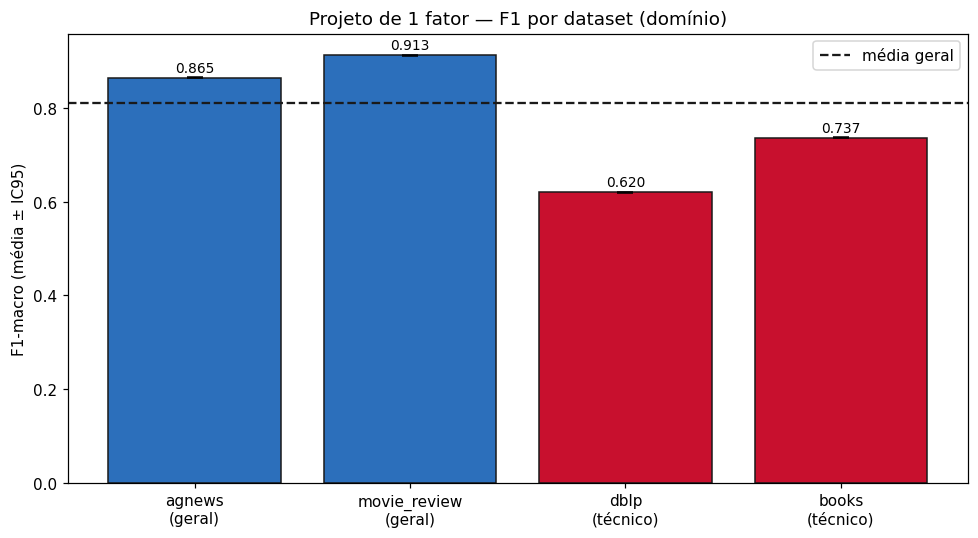

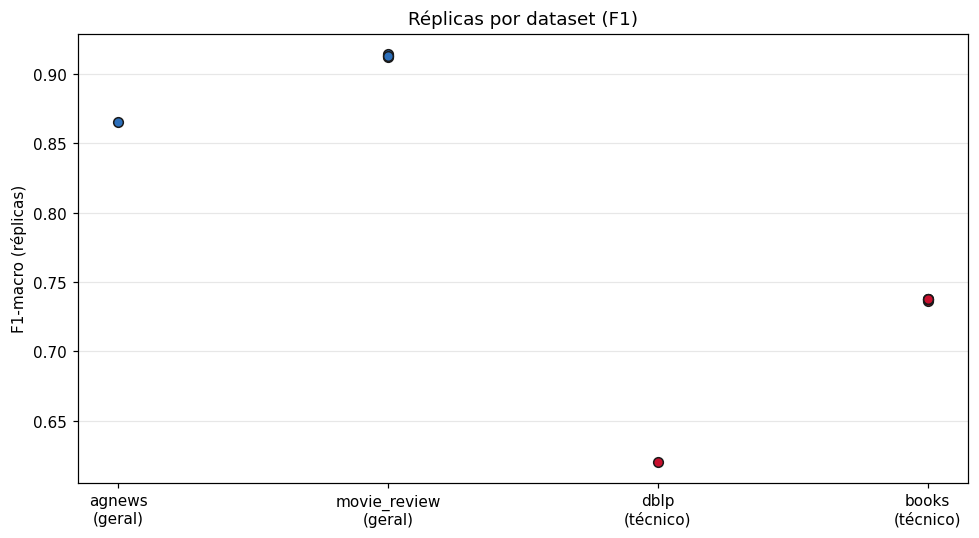

In [10]:
DOM_COR = {"geral": "#2c6fbb", "técnico": "#C8102E"}

# médias por dataset com IC 95%
fig, ax = plt.subplots(figsize=(9, 5))
niv = res_f1["niveis"]
xs = np.arange(len(niv))
yerr = [niv["media"] - niv["IC_low"], niv["IC_high"] - niv["media"]]
cores = [DOM_COR[DOMINIO[d]] for d in niv["dataset"]]
ax.bar(xs, niv["media"], yerr=yerr, capsize=5, color=cores, edgecolor="#1A1A1A")
ax.axhline(res_f1["grand_mean"], color="#1A1A1A", ls="--", label="média geral")
for x, m in zip(xs, niv["media"]):
    ax.annotate(f"{m:.3f}", (x, m), textcoords="offset points", xytext=(0, 4),
                ha="center", fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels([f"{d}\n({DOMINIO[d]})" for d in niv["dataset"]])
ax.set_ylabel("F1-macro (média ± IC95)")
ax.set_title("Projeto de 1 fator — F1 por dataset (domínio)")
ax.legend(); plt.tight_layout(); plt.show()

# dispersão das réplicas por dataset
fig, ax = plt.subplots(figsize=(9, 5))
for i, d in enumerate(DATASETS):
    sub = df1[df1["dataset"] == d]
    ax.scatter([i] * len(sub), sub["f1_macro"], color=DOM_COR[DOMINIO[d]], s=40,
               edgecolor="#1A1A1A", zorder=3)
ax.set_xticks(range(len(DATASETS)))
ax.set_xticklabels([f"{d}\n({DOMINIO[d]})" for d in DATASETS])
ax.set_ylabel("F1-macro (réplicas)")
ax.set_title("Réplicas por dataset (F1)")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

## 10) Resumo / interpretação

- A **Tabela ANOVA** (§7/§8) mostra se o **domínio** afeta significativamente a
  qualidade do consenso (F, p) e **quanto** da variação ele explica.
- Os **efeitos por nível** (§7) indicam quais datasets ficam acima/abaixo da média
  geral; o **Tukey HSD** diz **quais pares** diferem (controlando o erro global).
- As **premissas (§6)** dizem se devemos usar a resposta original ou a **logit**
  (provável, dado o padrão visto no fatorial).

> Enquanto **AGNews e DBLP** não tiverem as 5 réplicas, os resultados são
> **parciais/desbalanceados** — reexecute o notebook após a coleta para o desenho
> completo 4 × 5.

## 11) Exportar análise (.json) — `data/results/mq/um_fator_dominio`

In [11]:
EXPORT_DIR = ROOT / "data" / "results" / "mq" / "um_fator_dominio"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def _jsonable(o):
    if isinstance(o, pd.DataFrame):
        return o.to_dict(orient="records")
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, dict):
        return {k: _jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_jsonable(v) for v in o]
    return o


reps_por_dataset = {ds: int((df1["dataset"] == ds).sum()) for ds in DATASETS}
payload = {
    "design": "1 fator (domínio) — 4 níveis (datasets), resposta = consenso maioria",
    "niveis": DOMINIO,
    "n_reps_alvo": N_REPS,
    "reps_por_dataset": reps_por_dataset,
    "completo": all(v == N_REPS for v in reps_por_dataset.values()),
    "premissas": {
        "f1_macro": _jsonable(testar_premissas(df1, "f1_macro")),
        "accuracy": _jsonable(testar_premissas(df1, "accuracy")),
    },
    "observacoes": _jsonable(df1.drop(columns=["pasta"])),
    "anova": {
        "f1_macro": {"tabela": _jsonable(res_f1["anova"]), "niveis": _jsonable(res_f1["niveis"]),
                     "F": float(res_f1["F"]) if np.isfinite(res_f1["F"]) else None,
                     "p_value": res_f1["p_value"], "pct_fator": res_f1["pct_fator"]},
        "accuracy": {"tabela": _jsonable(res_acc["anova"]), "niveis": _jsonable(res_acc["niveis"]),
                     "F": float(res_acc["F"]) if np.isfinite(res_acc["F"]) else None,
                     "p_value": res_acc["p_value"], "pct_fator": res_acc["pct_fator"]},
    },
}

with open(EXPORT_DIR / "analise_um_fator_dominio.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
print("✓ Salvo em:", EXPORT_DIR, "| completo:", payload["completo"])

✓ Salvo em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\mq\um_fator_dominio | completo: False
